In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
sys.path.append('../../')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd

Выгружаем лонг и шорт данные 

In [92]:
# Лонг

import pandas as pd
import datetime as dt
import xgboost as xgb

companies_names = ['Whoosh'] # Bashneft, Sber, Positive, Whoosh, MMK
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(  # <------------ Вот сюда свою модель вставляем :)
            n_estimators=10000,
            learning_rate=0.02,
            max_depth=4,
            use_label_encoder=False,
            verbose=0,
            objective='binary:logistic',
            eval_metric="logloss",
            tree_method= 'hist',
            random_state=42,
            early_stopping_rounds=500,
            reg_lambda= 4.593,
            subsamples= 0.87,
        )

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
        )

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
[0]	validation_0-logloss:0.67327	validation_1-logloss:0.67879
[1]	validation_0-logloss:0.67183	validation_1-logloss:0.67757
[2]	validation_0-logloss:0.67047	validation_1-logloss:0.67637
[3]	validation_0-logloss:0.66913	validation_1-logloss:0.67524
[4]	validation_0-logloss:0.66782	validation_1-logloss:0.67416
[5]	validation_0-logloss:0.66656	validation_1-logloss:0.67307
[6]	validation_0-logloss:0.66533	validation_1-logloss:0.67206
[7]	validation_0-logloss:0.66412	validation_1-logloss:0.67110
[8]	validation_0-logloss:0.66297	validation_1-logloss:0.67011
[9]	validation_0-logloss:0.66181	validation_1-logloss:0.66910
[10]	validation_0-logloss:0.66071	val

In [93]:
# Шорт

import pandas as pd
import datetime as dt

companies_names = ['Whoosh']
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_1'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        
        model = xgb.XGBClassifier(  # <------------ Вот сюда свою модель вставляем :)
            n_estimators=10000,
            learning_rate=0.02,
            max_depth=3,
            use_label_encoder=False,
            verbose=0,
            objective='binary:logistic',
            eval_metric="logloss",
            tree_method= 'hist',
            random_state=42,
            early_stopping_rounds=500,
            reg_lambda= 9.82,
            subsamples=  0.52,
        )

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
        )
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_short_valid.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
[0]	validation_0-logloss:0.67750	validation_1-logloss:0.67945
[1]	validation_0-logloss:0.67650	validation_1-logloss:0.67856
[2]	validation_0-logloss:0.67546	validation_1-logloss:0.67779
[3]	validation_0-logloss:0.67453	validation_1-logloss:0.67699
[4]	validation_0-logloss:0.67355	validation_1-logloss:0.67628
[5]	validation_0-logloss:0.67266	validation_1-logloss:0.67555
[6]	validation_0-logloss:0.67174	validation_1-logloss:0.67490
[7]	validation_0-logloss:0.67092	validation_1-logloss:0.67425
[8]	validation_0-logloss:0.67005	validation_1-logloss:0.67364
[9]	validation_0-logloss:0.66922	validation_1-logloss:0.67302
[10]	validation_0-logloss:0.66843	val

Выгружаем графики метрик

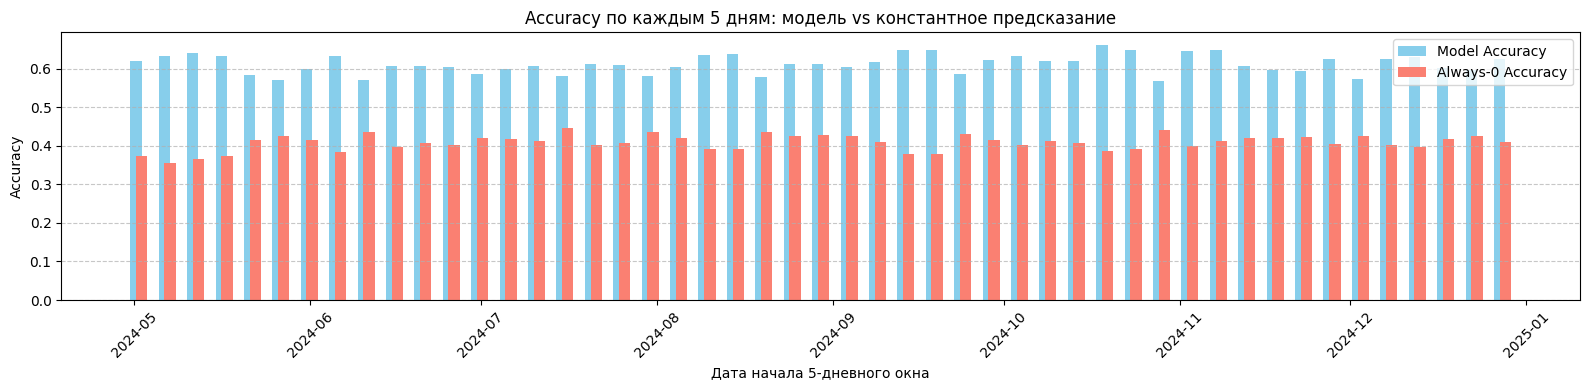

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_short_valid_cw025.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчёта accuracy модели и accuracy "всегда 0"
def compute_group_accuracy(group):
    acc_model = accuracy_score(group['target'], group['pred'])
    acc_dummy0 = accuracy_score(group['target'], [0] * len(group))
    return pd.Series({'accuracy_model': acc_model, 'accuracy_dummy0': acc_dummy0})

# Применяем по группам
grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()

# Добавим дату начала группы
grouped_accuracy['start_date'] = data.groupby('group_id')['utc'].min().values

# Строим barplot
plt.figure(figsize=(16, 4))
bar_width = 4  # Ширина одного столбца (в днях на оси X)

# Координаты по оси X
x = grouped_accuracy['start_date']

# Столбцы с accuracy модели (слева) и dummy (чуть правее)
plt.bar(x, grouped_accuracy['accuracy_model'], 
        width=2, label='Model Accuracy', color='skyblue', align='center')

plt.bar(x, grouped_accuracy['accuracy_dummy0'], 
        width=2, label='Always-0 Accuracy', color='salmon', align='edge')

# Подписи и оформление
plt.title('Accuracy по каждым 5 дням: модель vs константное предсказание')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

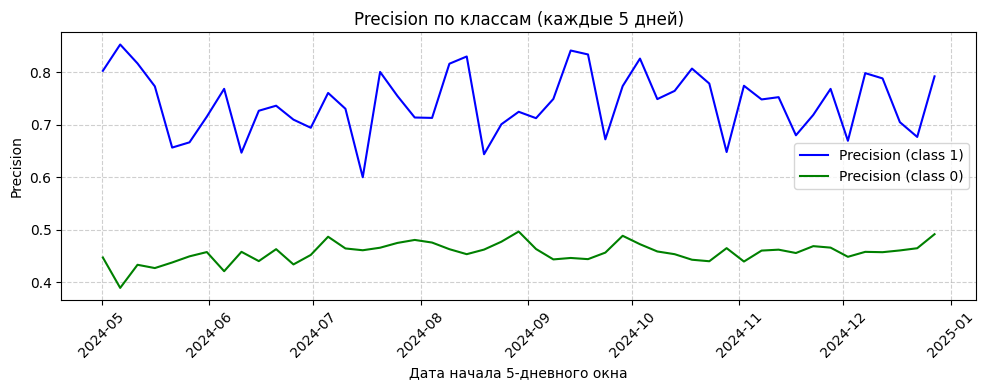

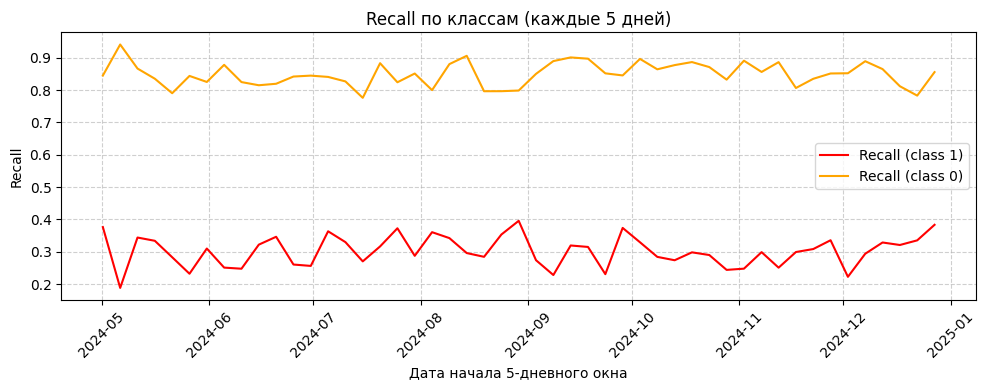

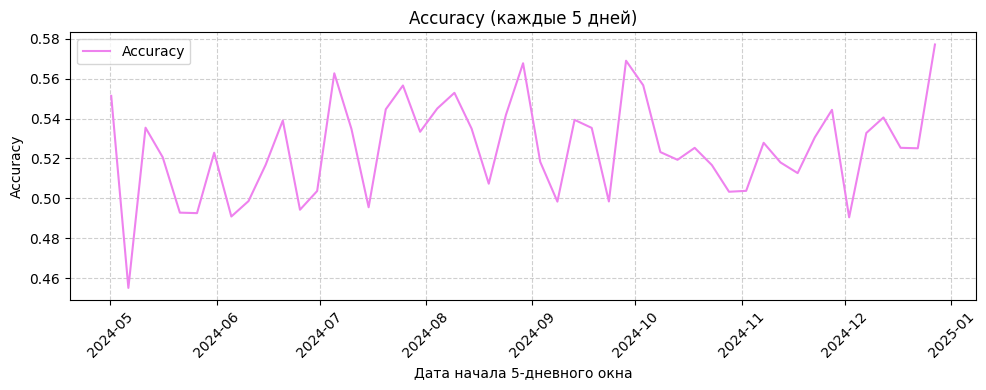

In [39]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_long_valid_cw01.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')


# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)


# Функция для расчета precision и recall по классам
def compute_precision_recall(group):
    y_true = group['target']
    y_pred = group['pred']
    accuracy = accuracy_score(y_true, y_pred)
    precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return pd.Series({
        'precision_1': precision_1,
        'precision_0': precision_0,
        'recall_1': recall_1,
        'recall_0': recall_0,
        'accuracy':  accuracy
    })

# Применяем по группам
metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()

# Добавим дату начала каждой группы
metrics_by_group['start_date'] = data.groupby('group_id')['utc'].min().values

# ----------------------- #
# 1. График Precision     #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_1'], label='Precision (class 1)', color='blue')
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_0'], label='Precision (class 0)', color='green')
plt.title('Precision по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 2. График Recall        #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_1'], label='Recall (class 1)', color='red')
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_0'], label='Recall (class 0)', color='orange')
plt.title('Recall по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 3. График Accuracy       #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['accuracy'], label='Accuracy', color='violet')
plt.title('Accuracy (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

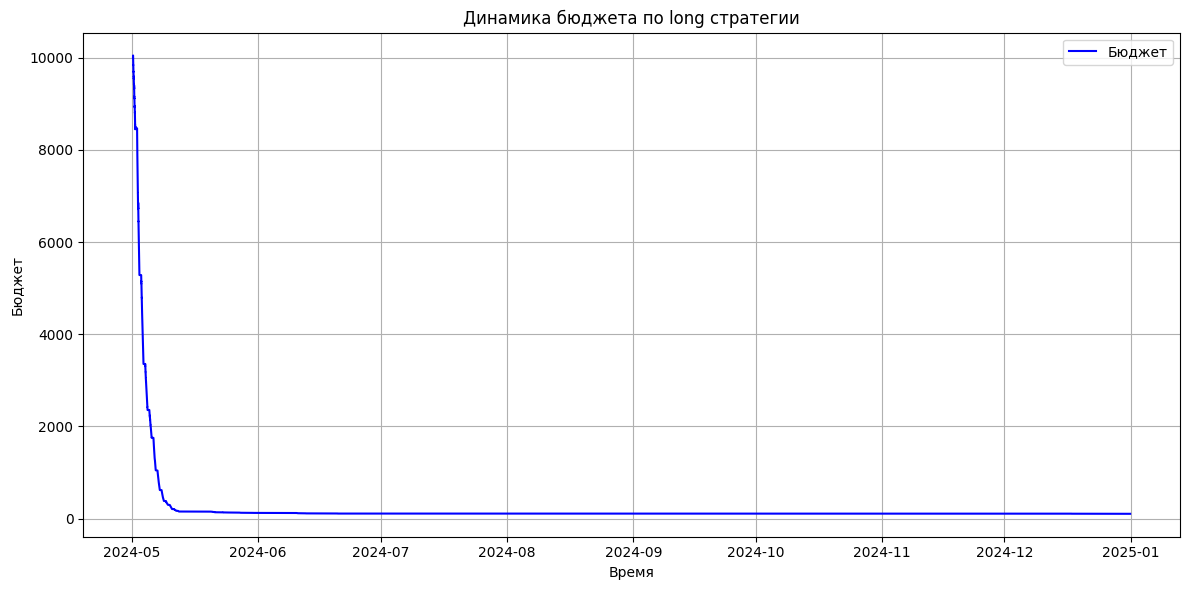

In [40]:
merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    # if signal == 1:  # Long
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         buy_cost = n_shares * price_now * (1 + commission_rate)
    #         sell_revenue = n_shares * price_next * (1 - commission_rate)
    #         budget += sell_revenue - buy_cost

    if signal == 0:  # Short
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            sell_proceeds = n_shares * price_now * (1 - commission_rate)
            buy_cost = n_shares * price_next * (1 + commission_rate)
            budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Подбор гиперпараметров

In [89]:
import datetime as dt
from sklearn.metrics import precision_score, recall_score, fbeta_score
import optuna
import numpy as np
import xgboost as xgb

# ваши подготовка дата/фрейма здесь не меняется
company_name = 'Whoosh'
df_path = '../../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)
cutoff_time = start_time - dt.timedelta(days=90)

findata = FinData(df_path)
findata.restrict_time_down(cutoff_time)
findata.restrict_time_up(end_time + dt.timedelta(days=2))
findata.insert_all()

cat_feats = findata.cat_features
num_feats = findata.numeric_features
target = 'direction_binary_0'

data = findata.df

def objective(trial):
    # weight_1 = trial.suggest_float("class_weight_1", 0.05, 1.0)
    depth = trial.suggest_int("max_depth", 2, 7)
    l2_lambda = trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)

    params = {
        'n_estimators': 10000,
        'learning_rate': 0.02,
        'max_depth': depth,
        'subsample': subsample,
        'reg_lambda': l2_lambda,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        # 'scale_pos_weight': weight_1,  # для бэлансировки классов, если нужен другой mapping – переделайте
        'early_stopping_rounds': 500,
        'verbosity': 0,
        'tree_method': 'hist',         # ускоряет на больших выборках, может заменить на 'gpu_hist' если на GPU
    }

    curr_time = start_time
    f_betas = []

    while curr_time < end_time:
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        if test_df.empty:
            break

        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba > 0.5).astype(int)
        f_betas.append(accuracy_score(y_test, preds))
        curr_time += dt.timedelta(days=5)

    final = np.mean(f_betas)
    return final

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=7)

print("Лучшие параметры:")
print(study.best_params)
print("Лучшее значение Accuracy:")
print(study.best_value)


[I 2025-07-06 18:53:42,345] A new study created in memory with name: no-name-de0a8d68-9ca3-4bcb-8990-ef27011ce4ec
[I 2025-07-06 18:54:55,985] Trial 0 finished with value: 0.6467928391157162 and parameters: {'max_depth': 4, 'reg_lambda': 4.5929164892585925, 'subsample': 0.8671146639665643}. Best is trial 0 with value: 0.6467928391157162.
[I 2025-07-06 18:56:03,505] Trial 1 finished with value: 0.6461098581895637 and parameters: {'max_depth': 3, 'reg_lambda': 0.007639172964606065, 'subsample': 0.8128488110541161}. Best is trial 0 with value: 0.6467928391157162.
[I 2025-07-06 18:57:12,619] Trial 2 finished with value: 0.6467288669262137 and parameters: {'max_depth': 3, 'reg_lambda': 1.0764768911426525, 'subsample': 0.8405592941236933}. Best is trial 0 with value: 0.6467928391157162.
[I 2025-07-06 18:59:23,546] Trial 3 finished with value: 0.644152539802004 and parameters: {'max_depth': 7, 'reg_lambda': 0.12990688320216348, 'subsample': 0.5609691212817904}. Best is trial 0 with value: 0.64

Лучшие параметры:
{'max_depth': 4, 'reg_lambda': 4.5929164892585925, 'subsample': 0.8671146639665643}
Лучшее значение Accuracy:
0.6467928391157162


In [90]:
import datetime as dt
from sklearn.metrics import precision_score, recall_score, fbeta_score
import optuna
import numpy as np
import xgboost as xgb

# ваши подготовка дата/фрейма здесь не меняется
company_name = 'Whoosh'
df_path = '../../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)
cutoff_time = start_time - dt.timedelta(days=90)

findata = FinData(df_path)
findata.restrict_time_down(cutoff_time)
findata.restrict_time_up(end_time + dt.timedelta(days=2))
findata.insert_all()

cat_feats = findata.cat_features
num_feats = findata.numeric_features
target = 'direction_binary_1'

data = findata.df

def objective(trial):
    # weight_1 = trial.suggest_float("class_weight_1", 0.05, 1.0)
    depth = trial.suggest_int("max_depth", 2, 7)
    l2_lambda = trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)

    params = {
        'n_estimators': 10000,
        'learning_rate': 0.02,
        'max_depth': depth,
        'subsample': subsample,
        'reg_lambda': l2_lambda,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        # 'scale_pos_weight': weight_1,  # для бэлансировки классов, если нужен другой mapping – переделайте
        'early_stopping_rounds': 500,
        'verbosity': 0,
        'tree_method': 'hist',         # ускоряет на больших выборках, может заменить на 'gpu_hist' если на GPU
    }

    curr_time = start_time
    f_betas = []

    while curr_time < end_time:
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        if test_df.empty:
            break

        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba > 0.5).astype(int)
        f_betas.append(accuracy_score(y_test, preds))
        curr_time += dt.timedelta(days=5)

    final = np.mean(f_betas)
    return final

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=7)

print("Лучшие параметры:")
print(study.best_params)
print("Лучшее значение Accuracy:")
print(study.best_value)


[I 2025-07-06 19:04:11,277] A new study created in memory with name: no-name-f6b1ff10-cfec-4009-942a-fd1877bdcb8f
[I 2025-07-06 19:06:35,342] Trial 0 finished with value: 0.6138140957172555 and parameters: {'max_depth': 7, 'reg_lambda': 1.8869239188499967, 'subsample': 0.7046296897329118}. Best is trial 0 with value: 0.6138140957172555.
[I 2025-07-06 19:08:47,075] Trial 1 finished with value: 0.6131933096223219 and parameters: {'max_depth': 7, 'reg_lambda': 0.0002110423830700321, 'subsample': 0.6404697612242205}. Best is trial 0 with value: 0.6138140957172555.
[I 2025-07-06 19:09:57,346] Trial 2 finished with value: 0.6147640499839535 and parameters: {'max_depth': 2, 'reg_lambda': 0.0002989036906514432, 'subsample': 0.6162084922713233}. Best is trial 2 with value: 0.6147640499839535.
[I 2025-07-06 19:11:13,536] Trial 3 finished with value: 0.6170303247555234 and parameters: {'max_depth': 3, 'reg_lambda': 9.81911133403299, 'subsample': 0.5185056340531584}. Best is trial 3 with value: 0.

Лучшие параметры:
{'max_depth': 3, 'reg_lambda': 9.81911133403299, 'subsample': 0.5185056340531584}
Лучшее значение Accuracy:
0.6170303247555234
